In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
heart_data = pd.read_csv("/content/drive/MyDrive/project/framingham_dataset.csv")

In [ ]:
heart_data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
heart_data.tail()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


Basic Info


In [ ]:
heart_data.info()
heart_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Handle Missing Values

In [5]:
heart_data = heart_data.fillna(heart_data.mean())

Spliting Features & Target

In [6]:
X = heart_data.drop(columns='TenYearCHD', axis=1)
Y = heart_data['TenYearCHD']

Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

# Step 1: 70% train, 30% temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, stratify=Y, random_state=2
)

# Step 2: split temp → 15% val, 15% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, stratify=Y_temp, random_state=2
)

Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Model Training

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Training Accuracy

In [11]:
from sklearn.metrics import accuracy_score

X_train_prediction = model.predict(X_train)
training_accuracy = accuracy_score(X_train_prediction, Y_train)

print("Training Accuracy:", training_accuracy)

Training Accuracy: 0.6667789757412399


Validation Accuracy


In [12]:
from sklearn.metrics import accuracy_score

Y_val_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(Y_val, Y_val_pred))

Validation Accuracy: 0.6965408805031447


Test Accuracy

In [13]:
X_test_prediction = model.predict(X_test)
test_accuracy = accuracy_score(X_test_prediction, Y_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.690251572327044


Prediction System

In [15]:
# Example input (15 features)
input_data = (1, 24, 4, 1, 100, 1, 0, 0, 0, 100, 70, 26.91, 80, 77, 112)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# IMPORTANT: scale input
input_data_scaled = scaler.transform(input_data_reshaped)

prob = model.predict_proba(input_data_scaled)[0][1]

if prob < 0.3:
    print(f"Low Risk (P={prob:.3f})")
elif prob < 0.6:
    print(f"Medium Risk (P={prob:.3f})")
else:
    print(f"High Risk (P={prob:.3f})")

Low Risk (P=0.179)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(Y_test, X_test_prediction))
print(classification_report(Y_test, X_test_prediction))

[[372 168]
 [ 29  67]]
              precision    recall  f1-score   support

           0       0.93      0.69      0.79       540
           1       0.29      0.70      0.40        96

    accuracy                           0.69       636
   macro avg       0.61      0.69      0.60       636
weighted avg       0.83      0.69      0.73       636



ROC curve

AUC Score: 0.7331983024691358


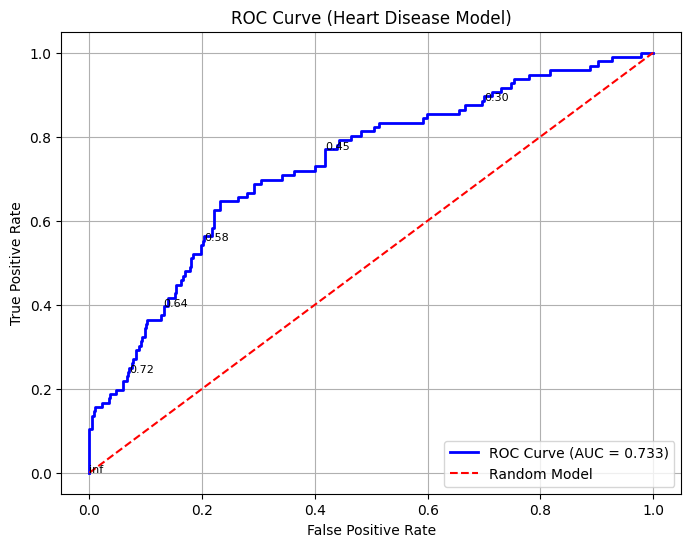

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
Y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

# AUC
auc_score = roc_auc_score(Y_test, Y_prob)

print("AUC Score:", auc_score)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f"ROC Curve (AUC = {auc_score:.3f})")

# Diagonal (random model)
plt.plot([0,1], [0,1], color='red', linestyle='--', label="Random Model")

# Mark important thresholds
for i in range(0, len(thresholds), max(1, len(thresholds)//6)):
    plt.text(fpr[i], tpr[i], f"{thresholds[i]:.2f}", fontsize=8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Heart Disease Model)")
plt.legend(loc="lower right")
plt.grid()

plt.show()